### NARX data interpretation

In [16]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path

# lag order for NARX regressor
lag = 5

# model settings
out_dim = 1
units = 32
n_epochs = 150
bs = 64
tol = 5
no_improve = 0

# Load data 
# data = np.load(
#     "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
# )

data_path = Path("../disc-benchmark-files/training-val-test-data.npz")
data = np.load(data_path)
y_raw = data["th"]
u_raw = data["u"]

def build_regressor_matrix(u, y, p):
    # stack lagged inputs and outputs into rows
    # each row: [u(k-p)...u(k-1), y(k-p)...y(k-1)] -> y(k)
    phi, targets = [], []
    for k in range(p, len(y)):
        phi.append(np.concatenate([u[k-p:k], y[k-p:k]]))
        targets.append(y[k])
    return np.array(phi), np.array(targets)

### Normalize data

In [17]:
# split and normalize
phi, targets = build_regressor_matrix(u_raw, y_raw, lag)

# last 30% as test set, no shuffle to keep time order
phi_tv, phi_test, t_tv, t_test = train_test_split(
    phi, targets, test_size=0.3, random_state=24, shuffle=False
)
phi_train, phi_val, t_train, t_val = train_test_split(
    phi_tv, t_tv, test_size=0.35, random_state=24, shuffle=True
)

# normalise using train stats only
x_mu = phi_train.mean(axis=0)
x_sig = phi_train.std(axis=0)
y_mu = t_train.mean()
y_sig = t_train.std()

phi_train = (phi_train - x_mu) / x_sig
phi_val = (phi_val - x_mu) / x_sig
phi_test = (phi_test - x_mu) / x_sig
t_train = (t_train - y_mu) / y_sig
t_val = (t_val - y_mu) / y_sig
t_test = (t_test - y_mu) / y_sig

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
phi_train, phi_val, phi_test = to_t(phi_train), to_t(phi_val), to_t(phi_test)
t_train, t_val, t_test = to_t(t_train), to_t(t_val), to_t(t_test)

input_size = phi_train.shape[1]

### simple neural network structure

In [18]:
# structure of the simple MLP model
class MLP(nn.Module):
    def __init__(self, n_in, n_out, n_hidden):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden).float()
        self.fc2 = nn.Linear(n_hidden, n_hidden).float()
        self.fc3 = nn.Linear(n_hidden, n_out).float()

    def forward(self, x):
        x = torch.sigmoid(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return self.fc3(x)[:, 0]


model = MLP(input_size, out_dim, units)
# Adam optimizer usually the best choice
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

### training loop for the simple NN model. Using the normalized NARX data

In [19]:
idx = np.arange(len(phi_train), dtype=int)
best_val = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    np.random.shuffle(idx)

    model.train()
    for i in range(0, len(phi_train), bs):
        batch = idx[i : i + bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred, t_train[batch])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        model.eval()
        v_rmse = loss_fn(model(phi_val), t_val).sqrt()
        t_rmse = loss_fn(model(phi_train), t_train).sqrt()

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}")

    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop at epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

model.load_state_dict(best_state)

# Save best model parameters
torch.save(best_state, "best_ann_model.pt")
print("ANN weights saved successfully!")

epoch 0  train 0.3927  val 0.4001
epoch 1  train 0.1498  val 0.1554
epoch 2  train 0.1322  val 0.1376
epoch 3  train 0.1179  val 0.1229
epoch 4  train 0.1069  val 0.1115
epoch 5  train 0.0964  val 0.1007
epoch 6  train 0.0913  val 0.0951
epoch 7  train 0.0821  val 0.0856
epoch 8  train 0.0786  val 0.0819
epoch 9  train 0.0710  val 0.0742
epoch 10  train 0.0668  val 0.0698
epoch 11  train 0.0620  val 0.0649
epoch 12  train 0.0595  val 0.0622
epoch 13  train 0.0592  val 0.0617
epoch 14  train 0.0538  val 0.0561
epoch 15  train 0.0493  val 0.0516
epoch 16  train 0.0455  val 0.0476
epoch 17  train 0.0448  val 0.0469
epoch 18  train 0.0404  val 0.0425
epoch 19  train 0.0382  val 0.0401
epoch 20  train 0.0335  val 0.0354
epoch 21  train 0.0348  val 0.0366
epoch 22  train 0.0281  val 0.0298
epoch 23  train 0.0259  val 0.0277
epoch 24  train 0.0231  val 0.0247
epoch 25  train 0.0245  val 0.0258
epoch 26  train 0.0216  val 0.0227
epoch 27  train 0.0196  val 0.0208
epoch 28  train 0.0172  val 0.

In [ ]:
def load_model(model):
    """ 
    Loads trained parameters into a model.

    Parameters
    ----------
    model:
        Model where the pre-trained parameters are to be loaded into.
        > reloaded_model = ANN(feats, out_dim, units).to(device)

    Returns
    -------
        The model with the pre-trained parameters.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    saved_weights = torch.load("best_rnn_model.pt", map_location=device)
    model.load_state_dict(saved_weights)
    return model

### Evuation of the model using test data split

RMS:  0.0074 rad  /  0.4252 deg
NRMS: 1.47%


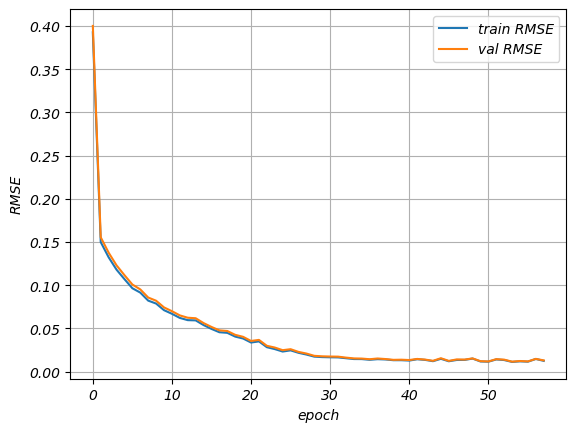

In [20]:
model.eval()
with torch.no_grad():
    pred_norm = model(phi_test).numpy()

# denormalise predictions and targets
pred_real = pred_norm * y_sig + y_mu
true_real = t_test.numpy() * y_sig + y_mu

rms = np.mean((pred_real - true_real) ** 2) ** 0.5
print(f"RMS:  {rms:.4f} rad  /  {rms / (2 * np.pi) * 360:.4f} deg")
print(f"NRMS: {rms / np.std(true_real) * 100:.2f}%")

plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist, label="val RMSE")
plt.xlabel("epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid()
plt.show()

### simulation of the model to predict outcomes

sim RMS:  0.1740 rad  /  9.9719 deg
sim NRMS: 36.31%


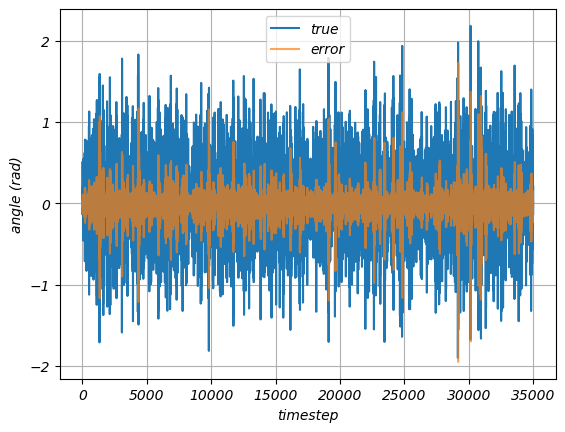

In [21]:
def simulate(f, u, y, skip=50, p=5, x_mu=None, x_sig=None, y_mu=None, y_sig=None):
    # use past values with ground truth during the burn in period
    upast = u[skip - p : skip].tolist()
    ypast = y[skip - p : skip].tolist()
    out = y[:skip].tolist()

    f.eval()
    for k in range(skip, len(u)):
        x = np.concatenate([upast, ypast])
        xt = torch.tensor((x - x_mu) / x_sig, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            yp = f(xt).item() * y_sig + y_mu
        out.append(yp)
        # append the buffers forward
        upast.append(u[k])
        upast.pop(0)
        ypast.append(yp)
        ypast.pop(0)

    return np.array(out)


sim = simulate(
    model, u_raw, y_raw, skip=lag, p=lag, x_mu=x_mu, x_sig=x_sig, y_mu=y_mu, y_sig=y_sig
)

err = sim[lag:] - y_raw[lag:]
rms_sim = np.mean(err**2) ** 0.5
print(f"sim RMS:  {rms_sim:.4f} rad  /  {rms_sim / (2 * np.pi) * 360:.4f} deg")
print(f"sim NRMS: {rms_sim / np.std(y_raw[lag:]) * 100:.2f}%")

plt.plot(y_raw, label="true")
plt.plot(sim - y_raw, label="error", alpha=0.7)
plt.xlabel("timestep")
plt.ylabel("angle (rad)")
plt.legend()
plt.grid()
plt.show()